<a href="https://colab.research.google.com/github/strugglerr123/Final/blob/master/GNSS_Denoising_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GNSS Signal Denoising (Simulated Dataset)
This Colab notebook demonstrates how to denoise GNSS-like signals using a Deep Autoencoder.
We simulate multipath interference and train a PyTorch model to clean it.


In [1]:
!pip install torch numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split


In [3]:
def generate_gnss_data(samples=10000, length=100):
    clean = np.sin(np.linspace(0, 10, length)) + np.random.normal(0, 0.05, (samples, length))
    multipath = clean + 0.5 * np.roll(clean, shift=3, axis=1)
    noise = np.random.normal(0, 0.1, multipath.shape)
    noisy = multipath + noise
    return noisy.astype(np.float32), clean.astype(np.float32)

X, Y = generate_gnss_data()
print("Data shape:", X.shape)


Data shape: (10000, 100)


In [4]:
class GNSSAutoencoder(nn.Module):
    def __init__(self, input_dim=100):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [5]:
X_tensor = torch.tensor(X)
Y_tensor = torch.tensor(Y)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

model = GNSSAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    train_loss = 0
    for noisy, clean in train_loader:
        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {train_loss / len(train_loader):.6f}")


Epoch 1, Loss: 0.059819
Epoch 2, Loss: 0.002568
Epoch 3, Loss: 0.002569
Epoch 4, Loss: 0.002567
Epoch 5, Loss: 0.002566
Epoch 6, Loss: 0.002563
Epoch 7, Loss: 0.002563
Epoch 8, Loss: 0.002562
Epoch 9, Loss: 0.002562
Epoch 10, Loss: 0.002560


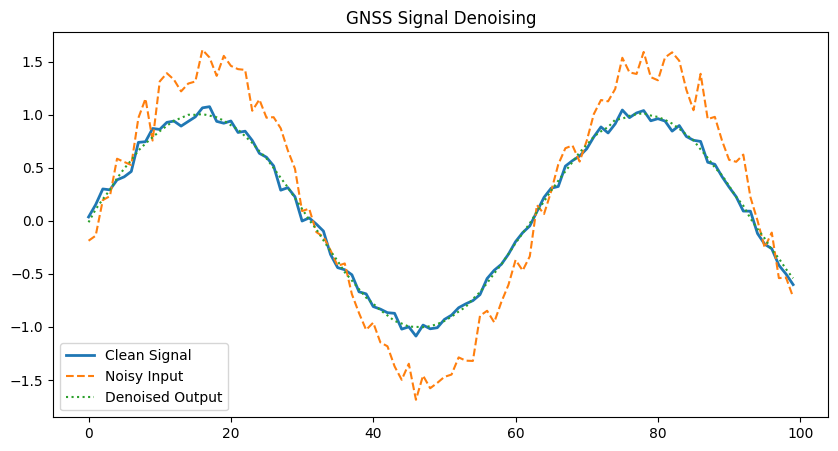

In [6]:
model.eval()
test_noisy = X_tensor[0:1]
test_clean = Y_tensor[0:1]
with torch.no_grad():
    test_denoised = model(test_noisy)

plt.figure(figsize=(10, 5))
plt.plot(test_clean[0].numpy(), label="Clean Signal", linewidth=2)
plt.plot(test_noisy[0].numpy(), label="Noisy Input", linestyle="--")
plt.plot(test_denoised[0].numpy(), label="Denoised Output", linestyle=":")
plt.legend()
plt.title("GNSS Signal Denoising")
plt.show()
